### [ 2025-11-04 데이터 분석 및 시각화 ]
- 데이터 :  titanic_train.csv
- (1) 생존자의 연령
- (2) 생존자의 성별
- (3) 생존자들의 연령과 성별 분석
- (4) 등석에 따른 생존자 분석

In [3]:
## 모듈 로딩
import matplotlib.pyplot as plt
import koreanize_matplotlib 
import pandas as pd

## 데이터 불러오기
titanic = pd.read_csv('../Data/titanic_train.csv')
display(titanic)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


[Survived] ---------- 2개
[0 1] 1 0
[Age] ---------- 88개
[22.   38.   26.   35.   54.    2.   27.   14.    4.   58.   20.   39.
 55.   31.   34.   15.   28.    8.   19.   40.   66.   42.   21.   18.
  3.    7.   49.   29.   65.   28.5   5.   11.   45.   17.   32.   16.
 25.    0.83 30.   33.   23.   24.   46.   59.   71.   37.   47.   14.5
 70.5  32.5  12.    9.   36.5  51.   55.5  40.5  44.    1.   61.   56.
 50.   36.   45.5  20.5  62.   41.   52.   63.   23.5   0.92 43.   60.
 10.   64.   13.   48.    0.75 53.   57.   80.   70.   24.5   6.    0.67
 30.5   0.42 34.5  74.  ] 80.0 0.42


C:\Users\kdt008\AppData\Local\Temp\ipykernel_16540\481202228.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.dropna(inplace=True)
C:\Users\kdt008\AppData\Local\Temp\ipykernel_16540\481202228.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['연령대'] = pd.cut(df1['Age'], bins=bins, labels=labels, right=True, include_lowest=True)


([<matplotlib.patches.Wedge at 0x1dc263f2a50>,
 [Text(0.7389907113689881, 0.8147961269608227, '20대'),
  Text(-0.8536093615773062, 0.693794679878409, '30대'),
  Text(-0.9363441694068383, -0.5772864076156811, '10대'),
  Text(-0.17796009446654285, -1.085509191475346, '10세 이하'),
  Text(0.6368855428266743, -0.8968705621985664, '40대'),
  Text(1.0262250832611415, -0.39605817563290274, '50대'),
  Text(1.0958716801322745, -0.09521166254228382, '60대'),
  Text(1.0999354549370695, -0.01191616433178328, '70대 이상')],
 [Text(0.4030858425649026, 0.4444342510695396, '26.6%'),
  Text(-0.46560510631489416, 0.37843346175185943, '25.2%'),
  Text(-0.5107331833128208, -0.31488349506309876, '14.1%'),
  Text(-0.09706914243629608, -0.592095922622916, '13.1%'),
  Text(0.34739211426909505, -0.4892021248355816, '11.7%'),
  Text(0.559759136324259, -0.21603173216340146, '6.9%'),
  Text(0.5977481891630588, -0.05193363411397298, '2.1%'),
  Text(0.5999647936020378, -0.006499725999154516, '0.3%')])

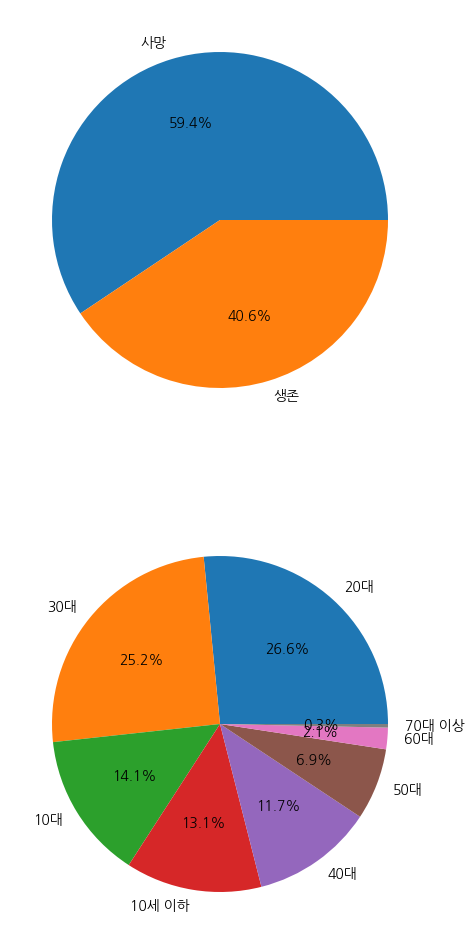

In [4]:
## 1. 생존자의 연령
## 전체에서 생존자 비율
## 생존자 중 연령 비율 (도넛 그래프로 할 예정)
 
## 데이터 전처리 --------------------------------------------------------------------------------------------------------------------------
df1 = titanic[['Survived' , "Age"]]
# df1.head()

## 결측치 체크
# df1.info()
## 결측치 제거
df1.dropna(inplace=True)
# df1.info()


## 이상치 확인 및 최연장자, 최연소 확인
for col in df1.columns :
    print(f'[{col}] ---------- {df1[col].nunique()}개')
    print(df1[col].unique(), df1[col].max(), df1[col].min())

## 연령대 컬럼 추가 ---------------------------------------------------------------------------------------------------------------------
# 구간 기준 정의
bins = [0, 10, 19, 29, 39, 49, 59, 69, 120]
labels = ['10세 이하', '10대', '20대', '30대', '40대', '50대', '60대', '70대 이상']

# pd.cut으로 구간별 레이블 생성
df1['연령대'] = pd.cut(df1['Age'], bins=bins, labels=labels, right=True, include_lowest=True)

# df1.head()

## 그래프 그리기 --------------------------------------------------------------------------------------------------------------------
## 생존자 비율
plt.figure(figsize = (8,12))
alive_per = df1['Survived'].value_counts()
# display(alive_per)
plt.subplot(2,1,1)
plt.pie(alive_per, labels=['사망', '생존'], autopct='%1.1f%%')

## 생존자 중 연령 비율
alive = df1[df1['Survived'] == 1]
age_per = alive['연령대'].value_counts()
plt.subplot(2,1,2)
plt.pie(age_per, labels=age_per.index, autopct='%1.1f%%')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Survived  891 non-null    int64 
 1   Sex       891 non-null    object
dtypes: int64(1), object(1)
memory usage: 14.1+ KB
[Survived] ---------- 2개
[0 1] 1 0
[Sex] ---------- 2개
['male' 'female'] male female


([<matplotlib.patches.Wedge at 0x1dc25cdad90>,
 [Text(-0.5931587604687747, 0.9263707059698871, 'female'),
  Text(0.5931586205906828, -0.9263707955343575, 'male')],
 [Text(-0.3235411420738771, 0.5052931123472111, '68.1%'),
  Text(0.3235410657767361, -0.5052931612005586, '31.9%')])

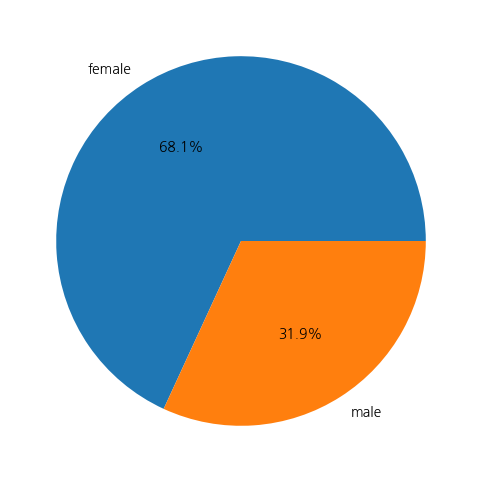

In [5]:
## (2) 생존자의 성별
## 성별 비율 (파이 그래프) 

## 데이터 전처리 -------------------------------------------------------------------
df2 = titanic[['Survived', 'Sex']]

## 결측치 없음!
df2.info()

## 이상치 탐색 ---> 없음
for col in df2.columns :
    print(f'[{col}] ---------- {df2[col].nunique()}개')
    print(df2[col].unique(), df2[col].max(), df2[col].min())


## 그래프 그리기 ================================================================
plt.figure(figsize = (6,6))
alive = df2[df2['Survived'] == 1]
gender_per = alive['Sex'].value_counts()
plt.pie(gender_per, labels= gender_per.index, autopct="%1.1f%%")


<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 1 to 889
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  342 non-null    int64  
 1   Sex       342 non-null    object 
 2   Age       290 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 10.7+ KB
[19, 7, 25, 23, 12, 4, 2, 1] [19, 34, 52, 50, 22, 16, 4, 0]


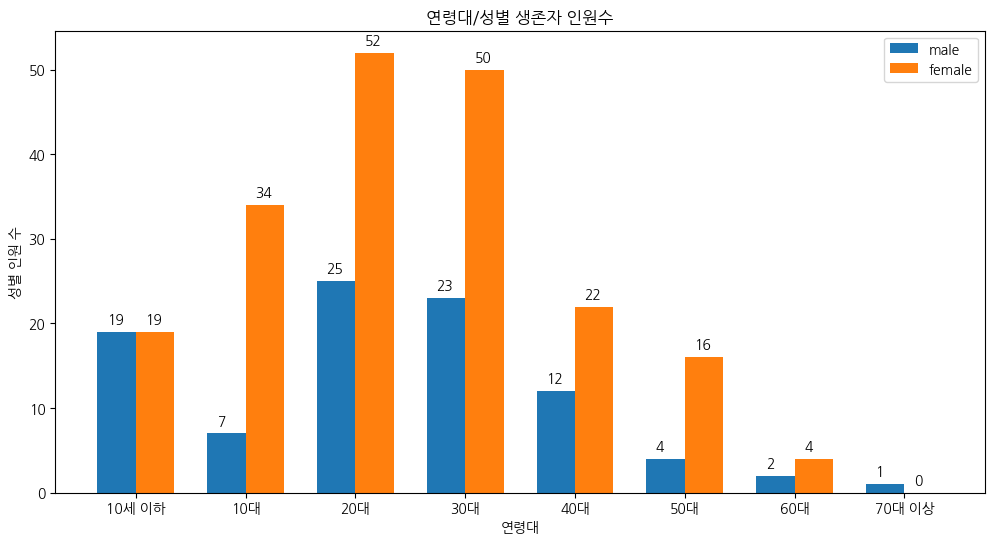

In [6]:
## 3. 연령별, 성별 그래프 
## 연령별 성별 막대그래프 그리기
## x인덱스 : 연령대
## y인덱스 : 성별 인원 수

## 데이터 전처리 ------------------------------------------------------------------
df3 = titanic[['Survived', 'Sex', 'Age']]
df3 = df3[df3['Survived'] == 1]

## 결측치 제거
df3.info()
df3.dropna()

## 연령대 컬럼 추가
# 구간 기준 정의
bins = [0, 10, 19, 29, 39, 49, 59, 69, 120]
labels = ['10세 이하', '10대', '20대', '30대', '40대','50대', '60대', '70대 이상']

# pd.cut으로 구간별 레이블 생성
df3['연령대'] = pd.cut(df3['Age'], bins=bins, labels=labels, right=True, include_lowest = True)
df3.head()


## 그래프 그리기 ------------------------------------------------------------

datax = pd.Series(range(len(labels)))
datay1 = [len(df3[(df3['Sex'] == 'male') & (df3['연령대'] == x)]) for x in labels]
datay2 = [len(df3[(df3['Sex'] == 'female') & (df3['연령대'] == x)]) for x in labels]

print(datay1,datay2)
W = 0.35

plt.figure(figsize= (12,6))

bar1 = plt.bar(datax-W/2, datay1, width =W)
bar2 = plt.bar(datax+W/2, datay2, width =W)
## 남자 막대 수치 넣기
for rect in bar1 :
    h, w, x = rect.get_height(), rect.get_width(), rect.get_x()
    plt.text(x+w/4, h+1, f'{h}')
## 여자 막대 수치 넣기
for rect in bar2 :
    h, w, x = rect.get_height(), rect.get_width(), rect.get_x()
    plt.text(x+w/4, h+1, f'{h}')
    
## 공통 부분
plt.title("연령대/성별 생존자 인원수")
plt.legend(['male', 'female'])  
plt.xticks(range(len(labels)), labels)
plt.xlabel("연령대")
plt.ylabel('성별 인원 수')
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Survived  891 non-null    int64
 1   Pclass    891 non-null    int64
dtypes: int64(2)
memory usage: 14.1 KB
[3 1 2]


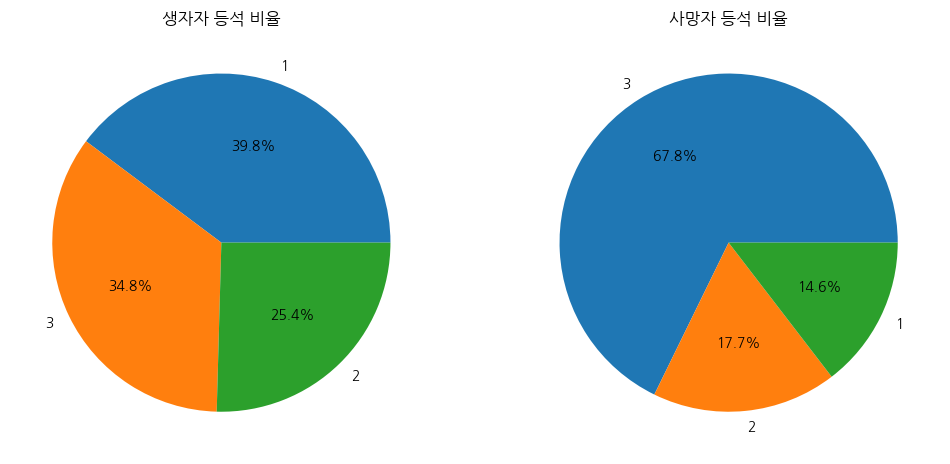

In [16]:
## (4) 등석에 따른 생존자 분석
## 죽은 사람의 등석 비교 
## 생존자의 등석 비율 비교

## 데이터 전처리 --------------------------------------------------------------------------------
df4 = titanic[['Survived', 'Pclass']]
df4_live = df4[df4['Survived'] == 1]
df4_die = df4[df4['Survived'] == 0]

## 결측치 없음
df4.info()

## 이상치 없음
print(df4['Pclass'].unique())


## 그래프 그리기 -----------------------------------------------------------------------------
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
live_per = df4_live['Pclass'].value_counts()
plt.pie(live_per, labels=live_per.index, autopct='%1.1f%%')
plt.title("생자자 등석 비율")

plt.subplot(1,2,2)
die_per = df4_die['Pclass'].value_counts()
plt.pie(die_per, labels=die_per.index, autopct='%1.1f%%')
plt.title("사망자 등석 비율")

plt.show()